# Exercise 2.3 — Steady 1D flow into a lake with a leaky bed

One-dimensional steady flow into a long, wide lake with a leaky bottom.

- **x = 0** at the lake shore
- **x < 0**: unconfined aquifer, constant discharge $Q_x = U$ (toward lake)
- **x ≥ 0**: semi-confined aquifer beneath the lake (leaky bed resistance $c$)
- Transmissivity approximated as constant $T$ everywhere

### Analytical solution

**For x ≤ 0** (constant $Q_x = U$, no leakage):
$$h(x) = h_L + \frac{U\lambda}{T} - \frac{U}{T}x, \qquad \lambda = \sqrt{cT}$$

**For x ≥ 0** (semi-confined, leaking into lake):
$$h(x) = h_L + \frac{U\lambda}{T}\,e^{-x/\lambda}$$

**Discharge vector** $Q_x$:
$$Q_x = U \quad (x \le 0), \qquad Q_x = U\,e^{-x/\lambda} \quad (x \ge 0)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Parameters

In [2]:
hL = 0.0   # water level in the lake, m
H  = 10.0  # aquifer thickness, m
T  = 20.0  # transmissivity, m2/d
U  = 0.02  # discharge vector in unconfined part, m2/d
c  = 100.0 # resistance of leaky lake bed, d

lam = np.sqrt(c * T)   # leakage factor, m
A   = U * lam / T      # head amplitude at x=0, m

print(f"Leakage factor  λ = {lam:.2f} m")
print(f"Head at x=0     h(0) = hL + Uλ/T = {hL + A:.4f} m")
print(f"95% of flow leaks within 3λ = {3*lam:.1f} m of the shore")

Leakage factor  λ = 44.72 m
Head at x=0     h(0) = hL + Uλ/T = 0.0447 m
95% of flow leaks within 3λ = 134.2 m of the shore


## Head and discharge functions

In [3]:
def head(x):
    """Hydraulic head as a function of x."""
    h = np.where(
        x <= 0,
        hL + A - (U / T) * x,          # linear in unconfined zone
        hL + A * np.exp(-x / lam)       # exponential below lake
    )
    return h

def disvec(x):
    """Discharge vector Qx as a function of x."""
    return np.where(
        x <= 0,
        U,                              # constant left of shore
        U * np.exp(-x / lam)            # decays exponentially below lake
    )

def leakage(x):
    """Vertical leakage flux qz (m/d), only defined for x >= 0."""
    return np.where(x >= 0, (head(x) - hL) / c, 0.0)

## Verify solution

Check that the numerical derivative of `head` matches `disvec`, and that
the integrated leakage equals the incoming discharge $U$.

In [4]:
delx = 1e-4  # small increment for numerical derivative

# --- Check Qx at a test point in the unconfined zone ---
x_test = -50.0
Qx_exact   = disvec(x_test)
Qx_numeric = -T * (head(x_test + delx) - head(x_test - delx)) / (2 * delx)
print(f"Unconfined zone (x={x_test} m)")
print(f"  Qx exact:   {Qx_exact:.8f} m2/d")
print(f"  Qx numeric: {Qx_numeric:.8f} m2/d")

# --- Check Qx at a test point below the lake ---
x_test2 = 50.0
Qx_exact2   = disvec(x_test2)
Qx_numeric2 = -T * (head(x_test2 + delx) - head(x_test2 - delx)) / (2 * delx)
print(f"\nSemi-confined zone (x={x_test2} m)")
print(f"  Qx exact:   {Qx_exact2:.8f} m2/d")
print(f"  Qx numeric: {Qx_numeric2:.8f} m2/d")

# --- Verify head and flux are continuous at x=0 ---
eps = 1e-10
print(f"\nContinuity at x=0")
print(f"  h(0-): {head(-eps):.6f}  h(0+): {head(eps):.6f}")
print(f"  Qx(0-): {disvec(-eps):.6f}  Qx(0+): {disvec(eps):.6f}")

# --- Verify total leakage equals U (integrate qz from 0 to inf analytically) ---
# integral of (A/c)*exp(-x/lam) dx from 0 to inf = A*lam/c = (Ulam/T)*(lam/c) = U*lam^2/(T*c) = U
total_leakage_analytic = A * lam / c
print(f"\nMass balance check")
print(f"  Incoming discharge U:           {U:.6f} m2/d")
print(f"  Integrated leakage (analytic):  {total_leakage_analytic:.6f} m2/d")

Unconfined zone (x=-50.0 m)
  Qx exact:   0.02000000 m2/d
  Qx numeric: 0.02000000 m2/d

Semi-confined zone (x=50.0 m)
  Qx exact:   0.00653844 m2/d
  Qx numeric: 0.00653844 m2/d

Continuity at x=0
  h(0-): 0.044721  h(0+): 0.044721
  Qx(0-): 0.020000  Qx(0+): 0.020000

Mass balance check
  Incoming discharge U:           0.020000 m2/d
  Integrated leakage (analytic):  0.020000 m2/d


## Plot 1 — Head and discharge profiles

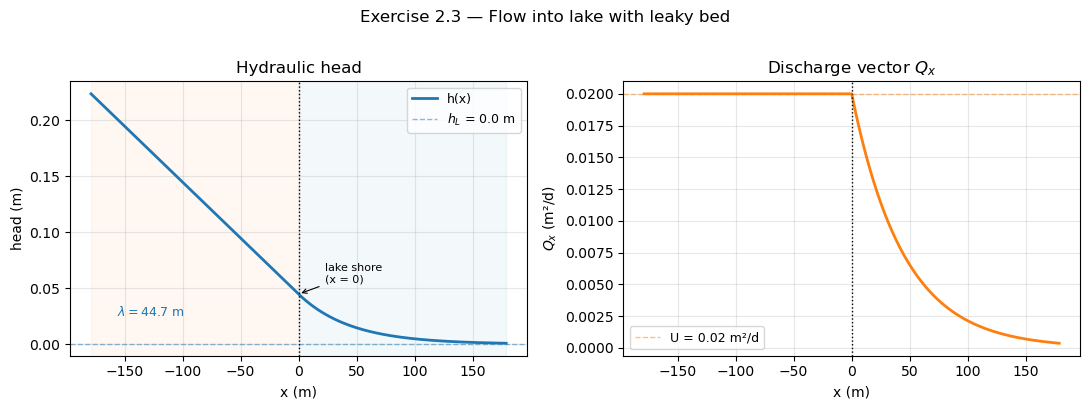

In [5]:
x = np.hstack([
    np.linspace(-4 * lam, 0, 201),
    np.linspace(0, 4 * lam, 201)
])

h  = head(x)
Qx = disvec(x)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Head profile ---
ax = axes[0]
ax.plot(x, h, 'C0', lw=2, label='h(x)')
ax.axhline(hL, color='C0', lw=1, ls='--', alpha=0.5, label=f'$h_L$ = {hL} m')
ax.axvline(0, color='k', lw=1, ls=':')
ax.annotate('lake shore\n(x = 0)', xy=(0, hL + A), xytext=(0.5*lam, hL + A + 0.01),
            fontsize=8, color='k',
            arrowprops=dict(arrowstyle='->', color='k', lw=0.8))
ax.set_xlabel('x (m)')
ax.set_ylabel('head (m)')
ax.set_title('Hydraulic head')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(-3.5*lam, hL + A*0.6, f'$\\lambda_{{}}={lam:.1f}$ m', fontsize=9, color='C0')

# shade regions
ax.axvspan(x.min(), 0, alpha=0.05, color='C1', label='unconfined')
ax.axvspan(0, x.max(), alpha=0.05, color='C0', label='semi-confined')

# --- Discharge profile ---
ax = axes[1]
ax.plot(x, Qx, 'C1', lw=2)
ax.axvline(0, color='k', lw=1, ls=':')
ax.axhline(U, color='C1', lw=1, ls='--', alpha=0.5, label=f'U = {U} m²/d')
ax.set_xlabel('x (m)')
ax.set_ylabel('$Q_x$ (m²/d)')
ax.set_title('Discharge vector $Q_x$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle('Exercise 2.3 — Flow into lake with leaky bed', fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

## Plot 2 — Streamlines in vertical cross section

The stream function $\psi$ satisfies:
$$Q_x = -\frac{\partial \psi}{\partial z}, \qquad q_z = \frac{\partial \psi}{\partial x}$$

For uniform horizontal flow in the unconfined zone, $\psi = -Q_x \cdot z + \text{const}$.
Streamlines are evenly spaced vertical columns on the left, then converge upward
through the leaky bed on the right.

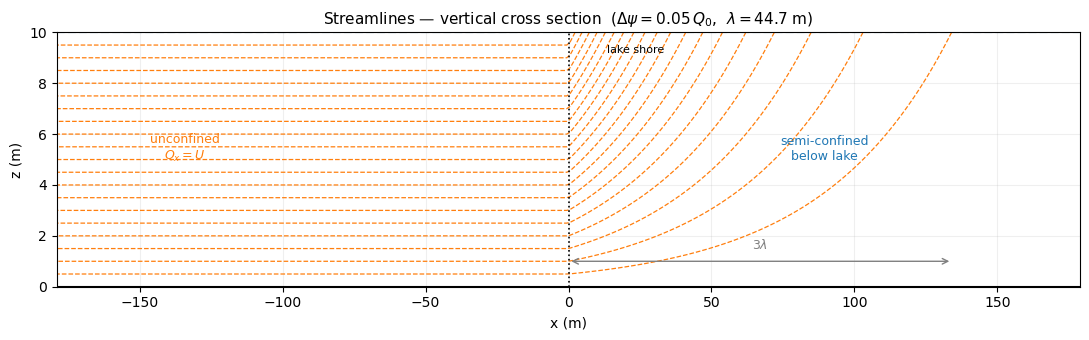

In [6]:
# Build stream function on a 2-D grid (x, z)
# psi(x, z) = -Qx(x) * (z/H)   (normalized so psi=0 at z=0, psi=-Qx at z=H)
# For plotting we use psi = Qx*(1 - z/H) so psi=Qx at bottom, 0 at top.

nx, nz = 300, 60
xg = np.linspace(-4 * lam, 4 * lam, nx)
zg = np.linspace(0, H, nz)
XG, ZG = np.meshgrid(xg, zg)

Qx2d = disvec(XG)
# stream function: psi decreases linearly with z
PSI = -Qx2d * ZG / H   # psi = 0 at bottom, -Qx at top

n_streamlines = 20
psi_levels = np.linspace(-U, 0, n_streamlines + 1)[1:-1]  # exclude boundaries

fig, ax = plt.subplots(figsize=(11, 3.5))

cs = ax.contour(XG, ZG, PSI, levels=psi_levels, colors='C1', linewidths=0.9)

# aquifer boundaries
ax.axhline(0, color='k', lw=1.5)
ax.axhline(H, color='C0', lw=1.5, ls='--', label='water table / top')

# lake shore
ax.axvline(0, color='k', lw=1.2, ls=':')
ax.text(0.3*lam, H*0.95, 'lake shore', fontsize=8, ha='left', va='top')

# region labels
ax.text(-3*lam, H*0.5, 'unconfined\n$Q_x = U$', fontsize=9, ha='center', color='C1')
ax.text( 2*lam, H*0.5, 'semi-confined\nbelow lake', fontsize=9, ha='center', color='C0')

# mark 3λ extents
ax.annotate('', xy=(3*lam, H*0.1), xytext=(0, H*0.1),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1))
ax.text(1.5*lam, H*0.15, '$3\\lambda$', ha='center', fontsize=9, color='gray')

ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title(f'Streamlines — vertical cross section  ($\\Delta\\psi = 0.05\\,Q_0$,  $\\lambda={lam:.1f}$ m)', fontsize=11)
ax.set_ylim(0, H)
ax.set_aspect('auto')
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

## Summary

| Quantity | Formula | Value |
|---|---|---|
| Leakage factor | $\lambda = \sqrt{cT}$ | — |
| Head at shore | $h(0) = h_L + U\lambda/T$ | — |
| Head for x ≤ 0 | $h_L + U\lambda/T - (U/T)x$ | linear |
| Head for x ≥ 0 | $h_L + (U\lambda/T)\,e^{-x/\lambda}$ | exponential |
| Total leakage | $\int_0^\infty q_z\,dx = U$ | mass balance ✓ |